In [ ]:
# OOM 실험 수행해야함..
python run.py --run_name exp_baselines_v2 --mode baselines --models FairEdit --datasets pokec_z pokec_n pokec_z_g pokec_n_g


### 분석 중요도 순

#### 본문 핵심 실험

In [ ]:
# Ablation study
# 3-level loss + FIW 각 구성요소의 기여도를 A0→A5로 단계적 입증. FairGate 설계의 necessity를 직접 보여주는 가장 중요한 실험.
!python run_ablation.py \
    --datasets pokec_z pokec_z_g pokec_n pokec_n_g german credit recidivism nba income \
    --stages A0 A1 A2 A3 A4 A5 

In [4]:
import pandas as pd
import os
output_file = 'outputs/exp_ablation.csv'
output_dir = 'outputs/analysis'

STAGES = {
    "A0": dict(
        label="GCN only",
        desc="No fairness loss, no FIW",
        lambda_fair=0.0,
        fips_lam=0.0,
        ablation_mode="none",        # struct/rep/out 모두 비활성
    ),
    "A1": dict(
        label="+ $\\mathcal{L}_{\\text{struct}}$",
        desc="Structural loss only",
        ablation_mode="struct_only",  # struct만 활성
        fips_lam=0.0,                 # uniform FIW (no uncertainty)
    ),
    "A2": dict(
        label="+ $\\mathcal{L}_{\\text{rep}}$",
        desc="Struct + representation loss",
        ablation_mode="struct_rep",
        fips_lam=0.0,
    ),
    "A3": dict(
        label="+ $\\mathcal{L}_{\\text{out}}$",
        desc="Full 3-level loss, uniform FIW",
        ablation_mode="full_loss",
        fips_lam=0.0,                 # uncertainty 비활성 → boundary-only FIW
    ),
    "A4": dict(
        label="+ FIW (boundary)",
        desc="Full loss + boundary-only FIW",
        ablation_mode="full_loss",
        fips_lam=0.0,                 # fips_lam=0 → uncertainty 가중치 없음
        sbrs_quantile_override=True,  # quantile 적용 (boundary gating 활성)
    ),
    "A5": dict(
        label="Full FairGate",
        desc="Full loss + hierarchical FIW",
        ablation_mode="full_loss",    # fips_lam=FAIRGATE_CONFIGS 기본값 사용
    ),
}

def analyze(output_file: str, output_dir: str):
    if not os.path.exists(output_file):
        print("[WARN] 결과 파일 없음"); return
    df = pd.read_csv(output_file)
    if "ablation_stage" not in df.columns:
        print("[WARN] ablation_stage 컬럼 없음"); return

    stage_order = list(STAGES.keys())
    metrics = ["acc_mean","roc_auc_mean","f1_mean","dp_mean","eo_mean"]
    metrics = [m for m in metrics if m in df.columns]

    # 데이터셋 × stage 피벗
    pivot = df.pivot_table(index="dataset", columns="ablation_stage",
                           values=metrics, aggfunc="mean")
    pivot.to_csv(os.path.join(output_dir, "ablation_comparison.csv"))

    # LaTeX
    datasets = [d for d in ["pokec_z","pokec_n","german","credit",
                              "recidivism","nba","income"] if d in df["dataset"].unique()]
    DNAME = {"pokec_z":"Pokec-Z","pokec_z_g":"Pokec-Z (g)","pokec_n":"Pokec-N",
             "pokec_n_g":"Pokec-N (g)","german":"German","credit":"Credit",
             "recidivism":"Recidivism","nba":"NBA","income":"Income"}
    show = ["roc_auc_mean","dp_mean","eo_mean"]
    show = [m for m in show if m in df.columns]

    lines = [r"\begin{table}[t]",r"\centering",
        r"\caption{Ablation study. 각 구성 요소를 순차적으로 추가하며 성능 변화를 측정. "
        r"A0: GCN only; A1: +$\mathcal{L}_\text{struct}$; A2: +$\mathcal{L}_\text{rep}$; "
        r"A3: +$\mathcal{L}_\text{out}$; A4: +FIW (boundary); A5: Full FairGate.}",
        r"\label{tab:ablation}",r"\setlength{\tabcolsep}{4pt}",
        r"\renewcommand{\arraystretch}{1.15}",r"\resizebox{\linewidth}{!}{",
        r"\begin{tabular}{l" + "rrr"*len(stage_order) + "}",r"\toprule"]

    hdr1 = r"\multirow{2}{*}{\textbf{Dataset}}"
    for s in stage_order:
        hdr1 += r" & \multicolumn{3}{c}{" + s + "}"
    lines.append(hdr1 + r" \\")
    for i in range(len(stage_order)):
        s = 2 + i*3
        lines.append(r"\cmidrule(lr){"+f"{s}-{s+2}"+"}")
    hdr2 = ""
    for _ in stage_order:
        hdr2 += r" & AUC & $\Delta$DP & $\Delta$EO"
    lines.append(hdr2 + r" \\")
    lines.append(r"\midrule")

    for ds in datasets:
        sub = df[df["dataset"]==ds]
        row = DNAME.get(ds, ds)
        for s in stage_order:
            sr = sub[sub["ablation_stage"]==s]
            for m in show:
                if sr.empty or m not in sr.columns:
                    row += " & —"
                else:
                    val = sr.iloc[0][m]
                    # A5 기준 best이면 굵게
                    row += f" & {val:.4f}"
        lines.append(row + r" \\")

    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    tex_path = os.path.join(output_dir, "ablation_comparison.tex")
    with open(tex_path, "w") as f:
        f.write("\n".join(lines))
    print(f"[Saved] {tex_path}")

analyze(output_file, output_dir)

[Saved] outputs/analysis/ablation_comparison.tex


In [ ]:
# Acc-Fairness trade-off curve
# λ_fair sweep으로 Pareto frontier 시각화. "FairGate가 baseline 대비 frontier 자체를 개선한다"는 주장의 직접 근거. 리뷰어가 가장 인상깊게 보는 figure.
!python run_tradeoff.py \
    --datasets pokec_z pokec_z_g pokec_n pokec_n_g german credit recidivism nba income

!python outputs/analysis/tradeoff_plot.py

# FIW gating 분석
# adaptive gating 설계(w_lhd 혼합)가 실제로 어떻게 작동하는지 시각적으로 보여줌. 모델 수정 후 결과가 달라졌으므로 반드시 재실행 필요.
!python analyze_fiw_gating.py \
    --datasets pokec_z pokec_z_g pokec_n pokec_n_g german credit recidivism nba income \
    --device cuda:1


#### 설계 검증 실험

In [ ]:
# Scale calibration 분석
# periodic recalibration vs warmup-only vs no-calibration 비교. 설계 결정의 정당성. Phase 1 완료 후 실행.
!python analyze_scale_calibration.py \
    --datasets pokec_z pokec_z_g pokec_n pokec_n_g german credit recidivism nba income \
    --conditions with_calibration warmup_only no_calibration \
    --output_dir outputs/analysis \
    --log_dir logs/scale_calibration

!python outputs/analysis/scale_calibration_plot.py

# Edge intervention 분석
# drop vs scale. 이미 drop으로 메인 실험 돌렸으므로 scale만 추가 실행하면 됨. graph_stats와 연결해서 regime별 패턴 분석.
!python run_edge_intervention.py \
    --datasets pokec_z pokec_z_g pokec_n pokec_n_g german credit recidivism nba income \
    --interventions drop scale \
    --output_dir outputs/analysis \
    --log_dir logs/edge_intervention

# alpha-beta 계산 방식 비교
# variance vs mutual_info vs uniform. 이미 결과 있음. 분석 스크립트만 돌리면 됨.
!python run_alpha_beta_exp.py
!python analyze_alpha_beta.py \
    --csv outputs/ablation/exp_ab_variance.csv \
          outputs/ablation/exp_ab_mutual_info.csv \
          outputs/ablation/exp_ab_uniform.csv
          
!python outputs/analysis/fiw_gating_plot.py

# sensitivity analysis
# λ_fair, struct_drop, τ(boundary_sat_thr) 등 파라미터 robust성 입증. τ 민감도 분석이 subsec_adaptive_gating.tex 서술을 뒷받침.
!python run_sensitivity.py \
    --datasets pokec_z pokec_z_g pokec_n pokec_n_g german credit recidivism nba income \
    --params lambda_fair struct_drop warm_up dp_eo_ratio sbrs_quantile \
    --output_dir outputs/analysis \
    --log_dir logs/sensitivity
    
!python outputs/analysis/sensitivity_plot.py

#### 보조 분석 실험

In [ ]:
# Backbone 범용성 검증 
# GCN / GraphSAGE / SGC 비교. 이미 결과 있음. 분석만 재실행.
!python analyze_backbone.py \
    --gcn  outputs/exp_fairgate_gcn.csv \
    --sage outputs/exp_fairgate_sage.csv \
    --sgc  outputs/exp_fairgate_sgc.csv
    
# Graph 구조 특성 분석 
# 이미 완료. adaptive gating 설계 근거 섹션과 연결. 수정된 모델로 FIW gating 분석 완료 후 graph_stats 업데이트만 확인.
# exp_fairgate.csv 있으면 자동 연결
!python analyze_graph_stats.py --fairgate_csv outputs/exp_fairgate_gcn.csv

# Scalability 분석
# 메인 실험 CSV에서 time_sec 기반 분석. 추가 실험 불필요. 마지막에 실행.
# exp_fairgate.csv 있으면 자동 연결
!python analyze_scalability.py \
        --fairgate_csv outputs/exp_fairgate_gcn.csv \
        --baseline_csv outputs/compare/exp_baselines.csv \
        --graph_stats  outputs/analysis/graph_stats.csv

[Saved] ./outputs/analysis/scalability.pdf


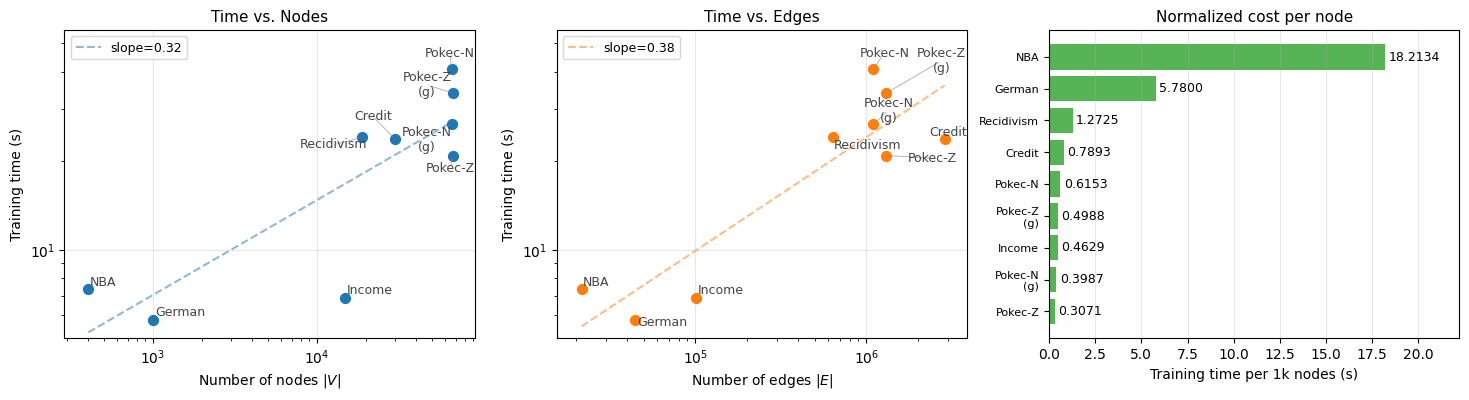

In [17]:
# Scalability 시각화
# !python ./outputs/analysis/scalability_plot.py

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

df = pd.read_csv(os.path.join('./outputs/analysis', "scalability.csv"))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
# fig.suptitle("FairGate Scalability Analysis", fontsize=13, fontweight="bold", y=1.02)

colors = plt.cm.tab10.colors

def add_scatter_with_repel_labels(ax, x, y, labels, color, xlabel, title):
    ax.scatter(x, y, color=color, s=50, zorder=3)

    # 먼저 축/스케일 설정
    ax.set_xscale("log")
    ax.set_yscale("log")

    # 바깥 여백 확보
    ax.set_xlim(np.min(x) / 1.4, np.max(x) * 1.35)
    ax.set_ylim(np.min(y) / 1.15, np.max(y) * 1.35)

    # 라벨 생성
    texts = []
    for xi, yi, label in zip(x, y, labels):
        label = label.replace(" (gender)", "\n(g)")
        texts.append(
            ax.text(
                xi, yi, label,
                fontsize=9,
                color="#444",
                zorder=4
            )
        )

    # 라벨 자동 충돌 회피
    adjust_text(
        texts,
        ax=ax,
        x=x,
        y=y,
        expand_points=(1.2, 1.4),
        expand_text=(1.2, 1.4),
        force_points=0.35,
        force_text=0.45,
        lim=300,
        arrowprops=dict(
            arrowstyle="-",
            color="#888",
            lw=0.6,
            alpha=0.7
        ),
        ensure_inside_axes=True,
        only_move={"points": "y", "text": "xy"},
    )

    # log-log fit
    lx = np.log(x.astype(float))
    ly = np.log(y.astype(float))
    coeffs = np.polyfit(lx, ly, 1)
    xfit = np.linspace(lx.min(), lx.max(), 100)

    ax.plot(
        np.exp(xfit),
        np.exp(np.polyval(coeffs, xfit)),
        "--",
        color=color,
        alpha=0.5,
        label=f"slope={coeffs[0]:.2f}",
        zorder=2
    )

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Training time (s)", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)


# ── (1) Nodes vs Time ──────────────────────────────────────────────────────────
add_scatter_with_repel_labels(
    ax=axes[0],
    x=df["nodes"].values.astype(float),
    y=df["time_sec_mean"].values.astype(float),
    labels=df["display_name"].tolist(),
    color=colors[0],
    xlabel="Number of nodes $|V|$",
    title="Time vs. Nodes",
)

# ── (2) Edges vs Time ──────────────────────────────────────────────────────────
add_scatter_with_repel_labels(
    ax=axes[1],
    x=df["edges"].values.astype(float),
    y=df["time_sec_mean"].values.astype(float),
    labels=df["display_name"].tolist(),
    color=colors[1],
    xlabel="Number of edges $|E|$",
    title="Time vs. Edges",
)

# ── (3) Time per 1k nodes (bar) ────────────────────────────────────────────────
ax = axes[2]
bar_df = df.sort_values("time_per_1k_nodes")
bar_labels = bar_df["display_name"].str.replace(" (gender)", "\n(g)", regex=False)

bars = ax.barh(bar_labels, bar_df["time_per_1k_nodes"], color=colors[2], alpha=0.8)

max_val = bar_df["time_per_1k_nodes"].max()
ax.set_xlim(0, max_val * 1.22)
ax.set_xlabel("Training time per 1k nodes (s)", fontsize=10)
ax.set_title("Normalized cost per node", fontsize=11)
ax.grid(True, axis="x", alpha=0.3)
ax.tick_params(axis="y", labelsize=8)

for bar, val in zip(bars, bar_df["time_per_1k_nodes"]):
    ax.text(
        bar.get_width() + max_val * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        ha="left",
        fontsize=9
    )

out = os.path.join('./outputs/analysis', "scalability.pdf")
plt.savefig(out, bbox_inches="tight", dpi=150)
print(f"[Saved] {out}")
plt.show()